In [75]:
import yaml
import glob
import pandas as pd

datasets = ['sdss_data', 'sdss_blue', 'ps_data', 'ps_blue', 'csp_data', 'csp_blue', 'swift_data', 'swift_blue']
samples = {}

for dataset in datasets:
    file_pattern = f'./mcmc_samples/mcmc_samples/mcmc_samples_{dataset}_*.yml'
    matching_files = glob.glob(file_pattern)
    print(matching_files)
    print(dataset)
    # Loop through all matching files
    for file_path in matching_files:
        # Initialize the list for the current dataset if not already done
        if dataset not in samples:
            samples[dataset] = []
        
        # Open and load the yaml file
        with open(file_path, 'r') as file:
            data = yaml.unsafe_load(file)  # It's better to use safe_load instead of unsafe_load for security
            samples[dataset].append(data)

    print(f"Loaded data from {len(matching_files)} files for dataset {dataset}.")
    

['./mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_110-120.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_20-30.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_50-60.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_40-50.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_80-90.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_70-80.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_90-100.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_0-10.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_30-40.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_140-150.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_130-140.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_100-110.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_150-160.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_150-159.yml', './mcmc_samples/mcmc_samples/mcmc_samples_sdss_data_10-20.yml', './mcmc_samples/mcmc_sample

In [76]:
import pandas as pd

# Dictionary to store dataframes for each dataset
dataframes = {}

# Assume 'samples' is the dictionary where the loaded data is stored for each dataset
datasets = samples.keys()  # This gives you all dataset names

# Loop through each dataset
for dataset in datasets:
    # Create a list to hold the rows of data
    data = []

    # Loop through each entry in the dataset
    for entry in samples[dataset]:
        object_ids = entry.get('object_id')  # Get the list of object_ids
        mean = entry.get('mean')
        std = entry.get('std')
        covariance = entry.get('covariance')

        # Create a separate row for each object_id
        for idx, obj_id in enumerate(object_ids):
            # Append a tuple of the data to the list
            data.append((obj_id, mean[idx], std[idx], covariance[idx]))

    # Create a DataFrame for the current dataset
    df = pd.DataFrame(data, columns=['object_id', 'mean', 'std', 'covariance'])
    
    # Set object_id as the index
    df.set_index('object_id', inplace=True)
    
    # Store the dataframe in the dictionary
    dataframes[dataset] = df

# Now you have a dictionary called 'dataframes' where each dataset has its own dataframe
# You can later use dataframes['dataset_name'] to access individual DataFrames


In [77]:
# List of keys for the normal data and their corresponding blue data
normal_blue_pairs = [
    ('sdss_data', 'sdss_blue'),
    ('ps_data', 'ps_blue'),
    ('csp_data', 'csp_blue'),
    ('swift_data', 'swift_blue')
]

# Iterate over each pair and combine the normal data with the corresponding blue data
for normal_key, blue_key in normal_blue_pairs:
    if normal_key in dataframes and blue_key in dataframes:
        # Merge the normal data with the blue data
        dataframes[normal_key] = dataframes[normal_key].join(
            dataframes[blue_key], rsuffix='_blue'
        )

# Now each normal data in `dataframes` will have its blue counterpart added as new columns.


In [78]:
import pandas as pd

# Initialize lists and dictionary to collect results across all datasets
unique_ids = []
duplicates = []
unconverted = {}
amp_none = []

# Loop over each dataset key in 'dataframes'
for dataset_name in ['sdss_data', 'ps_data', 'csp_data', 'swift_data']:
    dataset = dataframes[dataset_name]  # Get the current dataset

    # Loop over each row in the dataset
    for id, row in dataset.iterrows():
        if id not in unique_ids:
            unique_ids.append(id)
        else:
            duplicates.append(row)

        mean = dataset.loc[id]['mean']
        amplitude = mean.get('amplitude')

        if amplitude is None:
            print(f'{dataset_name} - Object ID {id} has None amplitude')
            amp_none.append(id)
        elif amplitude < 0.01:
            print(f'{dataset_name} - Object ID {id} has unconverted amplitude')
            unconverted.setdefault(id, []).append(amplitude)
            duplicates.append(row)  # Add unconverted rows to duplicates to be removed

    # Convert duplicates list to a DataFrame
    df = pd.DataFrame(duplicates)

    # Drop duplicates and unconverted amplitudes from the current dataset
    filtered_dataset = dataset.drop(df.index, errors='ignore')

    # Save the filtered dataset to CSV and Pickle
    filtered_dataset.to_csv(f'{dataset_name}_filtered.csv', index=True)
    filtered_dataset.to_pickle(f'{dataset_name}_filtered.pkl')

    # Store the filtered dataset back in 'dataframes' if needed
    dataframes[dataset_name] = filtered_dataset

    # Reset lists for the next dataset
    duplicates.clear()

print("Processing and saving completed for all datasets.")


sdss_data - Object ID SN2007pc has None amplitude
sdss_data - Object ID SN2007pc has None amplitude
sdss_data - Object ID SN2007pc has None amplitude
sdss_data - Object ID SN2007pc has None amplitude
sdss_data - Object ID SN2007pd has None amplitude
sdss_data - Object ID SN2007pd has None amplitude
sdss_data - Object ID SN2007pd has None amplitude
sdss_data - Object ID SN2007pd has None amplitude
sdss_data - Object ID SN2007ph has None amplitude
sdss_data - Object ID SN2007ph has None amplitude
sdss_data - Object ID SN2007ph has None amplitude
sdss_data - Object ID SN2007ph has None amplitude
sdss_data - Object ID SN2007pq has None amplitude
sdss_data - Object ID SN2007pq has None amplitude
sdss_data - Object ID SN2007pq has None amplitude
sdss_data - Object ID SN2007pq has None amplitude
sdss_data - Object ID SN2007pt has None amplitude
sdss_data - Object ID SN2007pt has None amplitude
sdss_data - Object ID SN2007pt has None amplitude
sdss_data - Object ID SN2007pt has None amplitude


In [90]:
for id in dataframes['swift_data'].index:
    mean = dataframes['swift_data'].loc[id]['mean']
    amplitude = mean.get('amplitude')

    if amplitude is None or amplitude < 0.01:
        print(f'We still need more work')

In [64]:
unique_ids=[]
duplicates=[]
unconverted={}
amp_none = []
dataset = filtered_dataset
for id, row in dataset.iterrows():
    if id not in unique_ids:
        unique_ids.append(id)
    else:
        duplicates.append(row)
    mean = dataset.loc[id]['mean']
    amplitude = mean.get('amplitude')

    if amplitude is None:
        print(f'Object ID {id} has None amplitude')
    elif  amplitude < 10e-3:
        print(f'Object ID {id} has unconverted amplitude')
        unconverted[id].append(amplitude)
print(f"duplicated ids are {duplicates} \n unconverted amplitudes are {unconverted}")

duplicated ids are [] 
 unconverted amplitudes are {}


KeyError: 's1'

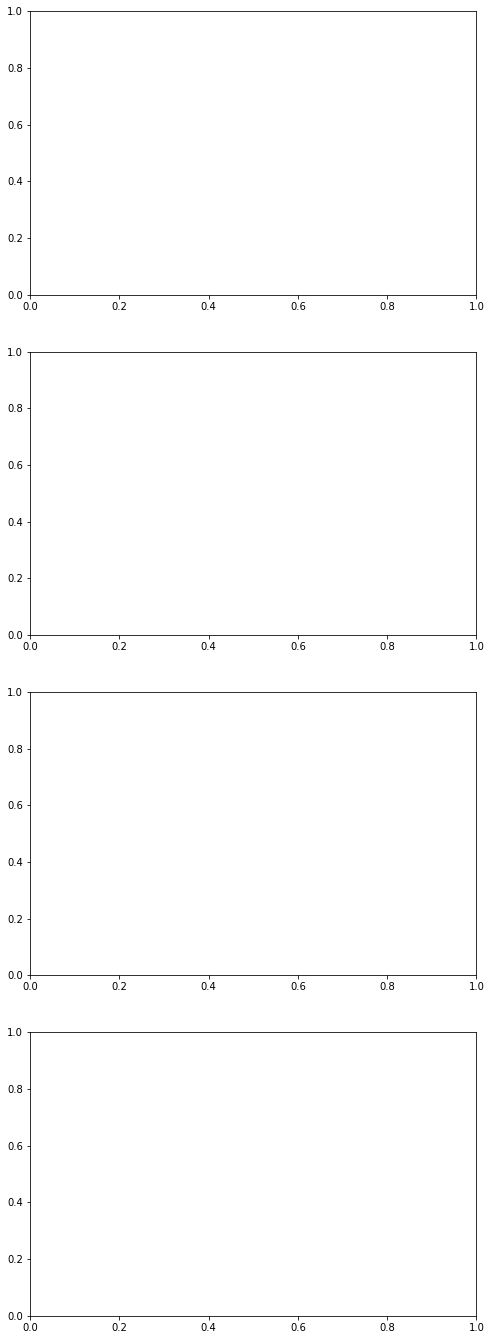

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bubble_diff(dataframes, dataset_key='sdss_data', normalize=False):
    """
    Plot the difference between summary_stats and blue_summary_stats for s1, s2, s3, and color
    for each individual light curve in the specified dataset.
    
    Parameters:
    - dataframes: Dictionary containing summary stats and blue stats in nested dictionaries (mean, std, covariance).
    - dataset_key: The key for the normal dataset to compare (default is 'sdss_data').
    - normalize: If True, normalize the data (default is False).
    """
    
    # Determine the blue dataset key by replacing 'data' with 'blue'
    blue_dataset_key = dataset_key.replace('data', 'blue')
    
    # List of parameters to plot
    parameters = ['s1', 's2', 's3', 'color']
    
    # Set up subplots
    fig, ax = plt.subplots(len(parameters), 1, figsize=(8, 24))
    
    # Function for normalization if selected
    def normalize_column(param_values):
        return (param_values - np.mean(param_values)) / np.std(param_values)
    
    # Extract the index (object_id) of each light curve
    object_ids = dataframes[dataset_key]['mean'].index  # Use the index as object_id
    
    # Initialize containers for normalized data and bubble sizes
    normalized_data = {param: [] for param in parameters}
    bubble_sizes = {param: [] for param in parameters}
    differences = {param: [] for param in parameters}
    mean_values = {param: [] for param in parameters}
    
    # Iterate over each light curve and calculate values
    for obj_id in object_ids:
        for param in parameters:
            # Mean values
            mean_value = dataframes[dataset_key]['mean'].loc[obj_id][param]  # Access dictionary value
            blue_mean_value = dataframes[blue_dataset_key]['mean'].loc[obj_id][param]  # Access blue dictionary value
            mean_values[param].append(mean_value)
            
            # Difference between normal and blue
            differences[param].append(mean_value - blue_mean_value)
            
            # Bubble size (based on standard deviations)
            std_value = dataframes[dataset_key]['std'].loc[obj_id][param]  # Access standard deviation value
            bubble_sizes[param].append(std_value * 500)
    
    # Normalize if required
    if normalize:
        for param in parameters:
            mean_values[param] = normalize_column(np.array(mean_values[param]))
            differences[param] = normalize_column(np.array(differences[param]))
    
    # Plot each parameter
    for i, param in enumerate(parameters):
        ax[i].scatter(mean_values[param], differences[param], 
                      s=bubble_sizes[param], label=f"{param}_diff", alpha=0.6)
        ax[i].set_xlabel(f'{param}_mean')
        ax[i].set_ylabel(f'{param}_diff')
        ax[i].set_title(f'Bubble Plot: {param}_diff (Bubble size represents error)')
        ax[i].legend()
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_bubble_diff(dataframes, dataset_key='ps_data', normalize=False)


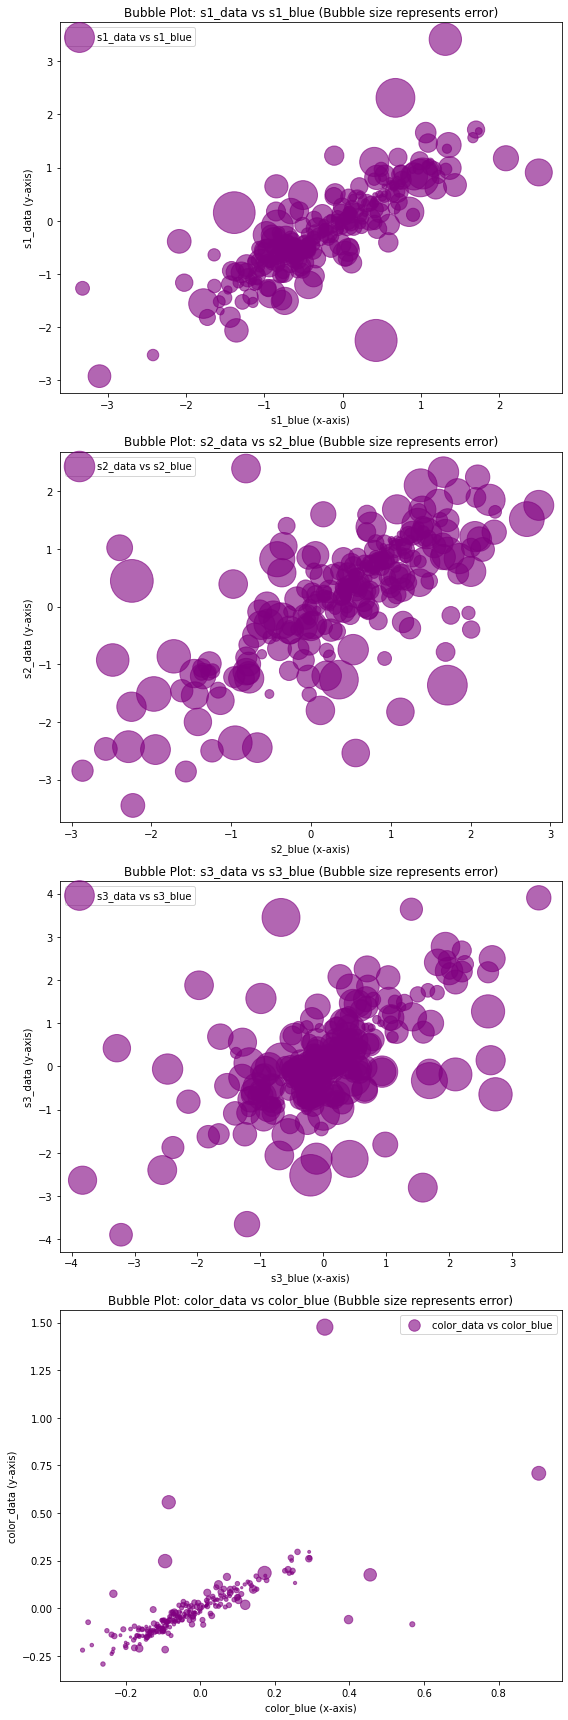

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bubble_comparison(dataframes, dataset_key='sdss_data', normalize=False):
    """
    Plot the actual values from the blue dataset on the x-axis and the normal dataset on the y-axis 
    for s1, s2, s3, and color for each individual light curve.
    
    Parameters:
    - dataframes: Dictionary containing summary stats and blue stats in nested dictionaries (mean, std, covariance).
    - dataset_key: The key for the normal dataset to compare (default is 'sdss_data').
    - normalize: If True, normalize the data (default is False).
    """
    
    # Determine the blue dataset key by replacing 'data' with 'blue'
    blue_dataset_key = dataset_key.replace('data', 'blue')
    
    # List of parameters to plot
    parameters = ['s1', 's2', 's3', 'color']
    
    # Set up subplots
    fig, ax = plt.subplots(len(parameters), 1, figsize=(8, 24))
    
    # Function for normalization if selected
    def normalize_column(param_values):
        return (param_values - np.mean(param_values)) / np.std(param_values)
    
    # Extract the index (object_id) of each light curve
    object_ids = dataframes[dataset_key]['mean'].index  # Use the index as object_id
    
    # Initialize containers for normalized data and bubble sizes
    mean_values = {param: [] for param in parameters}
    blue_mean_values = {param: [] for param in parameters}
    bubble_sizes = {param: [] for param in parameters}
    
    # Iterate over each light curve and calculate values
    for obj_id in object_ids:
        for param in parameters:
            # Mean values for normal and blue data
            mean_value = dataframes[dataset_key]['mean'].loc[obj_id][param]  # Access dictionary value
            blue_mean_value = dataframes[blue_dataset_key]['mean'].loc[obj_id][param]  # Access blue dictionary value
            mean_values[param].append(mean_value)
            blue_mean_values[param].append(blue_mean_value)
            
            # Bubble size (based on standard deviations)
            std_value = dataframes[dataset_key]['std'].loc[obj_id][param]  # Access standard deviation value
            bubble_sizes[param].append(std_value * 500)
    
    # Normalize if required
    if normalize:
        for param in parameters:
            mean_values[param] = normalize_column(np.array(mean_values[param]))
            blue_mean_values[param] = normalize_column(np.array(blue_mean_values[param]))
    
    # Plot each parameter
    for i, param in enumerate(parameters):
        # Plot blue data on the x-axis and normal data on the y-axis
        ax[i].scatter(blue_mean_values[param], mean_values[param], 
                      s=bubble_sizes[param], label=f"{param}_data vs {param}_blue", color="purple", alpha=0.6)
        
        ax[i].set_xlabel(f'{param}_blue (x-axis)')
        ax[i].set_ylabel(f'{param}_data (y-axis)')
        ax[i].set_title(f'Bubble Plot: {param}_data vs {param}_blue (Bubble size represents error)')
        ax[i].legend()
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_bubble_comparison(dataframes, dataset_key='ps_data', normalize=False)


In [19]:
# Define the modified data structure that will store filtered values
dataframes_mod = {}

# Threshold to filter outliers
color_threshold = 0.4
datasets = ['sdss_data', 'ps_data', 'csp_data', 'swift_data']
# Iterate over datasets to process
for dataset in datasets:
    # Initialize lists to store filtered values
    filtered_colors = []
    filtered_colors_blue = []
    filtered_s1 = []
    filtered_s2 = []
    filtered_s3 = []
    filtered_s1_blue = []
    filtered_s2_blue = []
    filtered_s3_blue = []

    # Iterate over the data points in each dataset
    for idx in range(len(dataframes[dataset])):
        # Access the mean values from both the normal and blue datasets
        values = dataframes[dataset]['mean'][idx]
        blue_values = dataframes[dataset]['mean_blue'][idx]
        
        # Apply the outlier filtering based on the color threshold (0.4)
        if values['color'] <= color_threshold and blue_values['color'] <= color_threshold:
            # If the condition is met, append the values to the respective lists
            filtered_colors.append(values['color'])
            filtered_colors_blue.append(blue_values['color'])
            filtered_s1.append(values['s1'])
            filtered_s2.append(values['s2'])
            filtered_s3.append(values['s3'])
            filtered_s1_blue.append(blue_values['s1'])
            filtered_s2_blue.append(blue_values['s2'])
            filtered_s3_blue.append(blue_values['s3'])
    
    # Save the filtered data in the new modified dataframes structure
    dataframes_mod[dataset] = {
        'filtered_colors': filtered_colors,
        'filtered_colors_blue': filtered_colors_blue,
        'filtered_s1': filtered_s1,
        'filtered_s2': filtered_s2,
        'filtered_s3': filtered_s3,
        'filtered_s1_blue': filtered_s1_blue,
        'filtered_s2_blue': filtered_s2_blue,
        'filtered_s3_blue': filtered_s3_blue
    }

# Convert the modified data to a DataFrame for easier analysis
filtered_dataset_mod = pd.DataFrame(dataframes_mod)
print(filtered_dataset_mod)


                                                              sdss_data  \
filtered_colors       [0.17414554383301417, 0.10029810788018237, -0....   
filtered_colors_blue  [0.06047330105301756, 0.1136231227343873, -0.0...   
filtered_s1           [-0.15519705987797566, -0.015571765519804598, ...   
filtered_s2           [2.547833697013498, 0.6781095693339911, -1.084...   
filtered_s3           [-0.8839981846255792, -0.6595856284211615, -0....   
filtered_s1_blue      [-2.3078369742020723, 0.3150586695495767, 0.52...   
filtered_s2_blue      [0.48603366939177295, 1.504608326280387, -0.77...   
filtered_s3_blue      [2.6861548486338247, 0.7366595788783707, 0.129...   

                                                                ps_data  \
filtered_colors       [-0.10281842171677372, 0.09972154576896397, -0...   
filtered_colors_blue  [-0.1025886182668059, 0.15169787193396297, -0....   
filtered_s1           [-0.5101152552712821, 0.35437313526647146, -1....   
filtered_s2           [1

In [14]:
dataframes['sdss_blue']['covariance'][2]


array([[ 1.53507462e-02, -2.21904306e-03,  1.12723531e-04,
        -1.26436009e-02,  1.85623201e-02, -1.79757044e-03],
       [-2.21904306e-03,  1.31207789e-02, -1.37212366e-03,
         8.91784914e-03, -1.71460757e-02,  2.25036361e-03],
       [ 1.12723531e-04, -1.37212366e-03,  1.78599318e-04,
        -7.90610149e-04,  6.46475098e-05, -9.48004136e-05],
       [-1.26436009e-02,  8.91784914e-03, -7.90610149e-04,
         5.73364090e-02, -5.81604583e-02,  1.16109252e-02],
       [ 1.85623201e-02, -1.71460757e-02,  6.46475098e-05,
        -5.81604583e-02,  1.81251247e-01, -3.93999833e-02],
       [-1.79757044e-03,  2.25036361e-03, -9.48004136e-05,
         1.16109252e-02, -3.93999833e-02,  9.89208669e-02]])

In [11]:
import numpy as np

def calculate_covariance(dataframes, dataset_key='sdss_data'):
    """
    Calculate the covariance between normal data and blue data for each parameter (s1, s2, s3, color)
    for each supernova.
    
    Parameters:
    - dataframes: Dictionary containing summary stats for both normal and blue datasets.
    - dataset_key: The key for the normal dataset to compare (default is 'sdss_data').
    
    Returns:
    - covariances: Dictionary containing 4x4 covariance matrices for each object (supernova).
    """
    
    
    # List of parameters for which to calculate covariance
    parameters = ['s1', 's2', 's3', 'color']
    
    # Extract the object IDs from the normal dataset
    object_ids = dataframes[dataset_key]['mean'].index  # Use the index as object_id
    
    covariances = {}
    plt.ylabel('Distance Modulus + offset')
    for obj_id in object_ids:
        # Extract mean values for the current supernova for both normal and blue datasets
        normal_values = np.array([dataframes[dataset_key]['mean'].loc[obj_id][param] for param in parameters])
        blue_values = np.array([dataframes[dataset_key]['mean_blue'].loc[obj_id][param] for param in parameters])
        #print(blue_values)
        covariances[obj_id] = np.cov(normal_values, blue_values)
    return covariances


KeyError: 's1'

In [10]:
for i in covariances.values():
    print(i)

NameError: name 'covariances' is not defined

In [10]:
ps_cov = calculate_covariance(dataframes, dataset_key='ps_data')
print(ps_cov)

[[ 0.59143568 -0.05089276 -0.13855267  0.02996326]
 [-0.08413036  0.75646155 -0.05451425  0.02778817]
 [-0.24425069 -0.09474862  0.6560415  -0.00095925]
 [ 0.02362713  0.01040999  0.00163607  0.01566603]]


In [11]:
csp_cov = calculate_covariance(dataframes, dataset_key='csp_data')
print(csp_cov)

[[ 0.50610213 -0.0139212  -0.06745962  0.0070465 ]
 [-0.04399327  0.21517012  0.06644602  0.03124341]
 [-0.20930438  0.05537131  0.1745182   0.00531563]
 [ 0.01220624  0.03286755  0.02302394  0.01389585]]


In [12]:
swift_cov = calculate_covariance(dataframes, dataset_key='swift_data')
print(swift_cov)

[[ 0.6312054   0.05802982 -0.03985919  0.00353374]
 [ 0.30036353  0.41620093 -0.24679189  0.04403927]
 [-0.12780567 -0.41444887  0.41429273 -0.01529139]
 [ 0.02094316  0.00830741 -0.02493582  0.01154277]]


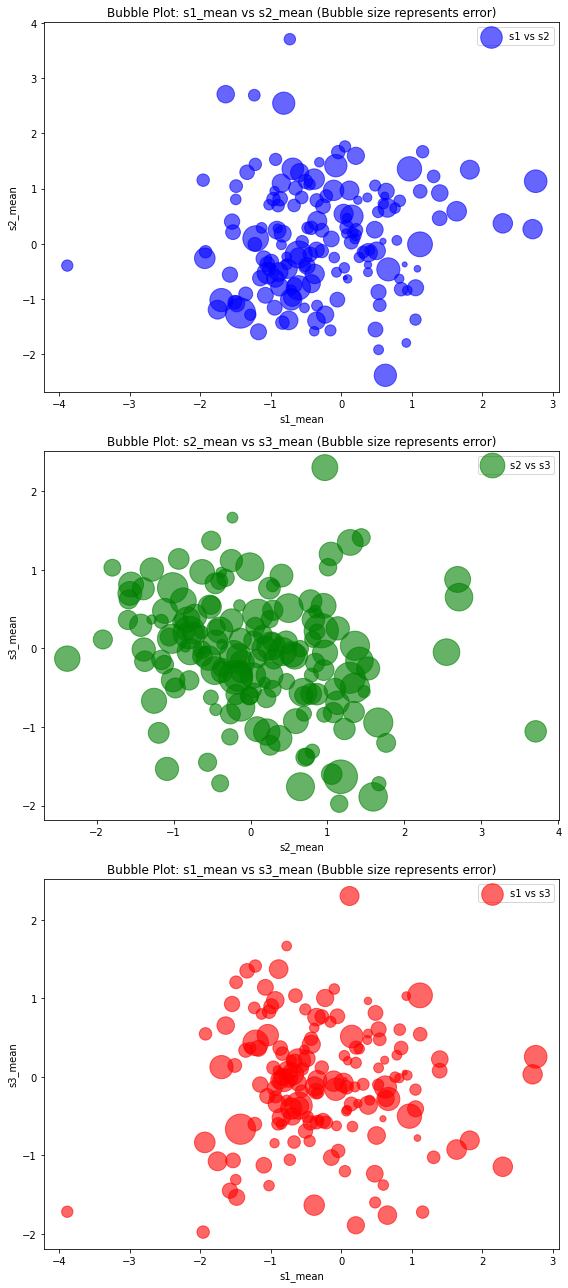

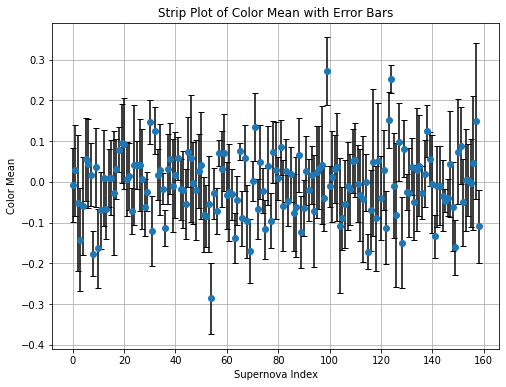

In [20]:
# Applying the bubble size error representation to the three scatter plots and replacing violin plot with a boxplot for color_mean
import matplotlib.pyplot as plt
import pandas as pd
# Scatter plot with bubble sizes to represent errors
fig, ax = plt.subplots(3, 1, figsize=(8, 18))

# Bubble plot s1_mean vs s2_mean
bubble_size_s1_s2 = blue_summary_stats['s1_stddev'] * 500
ax[0].scatter(blue_summary_stats['s1_mean'], blue_summary_stats['s2_mean'], 
              s=bubble_size_s1_s2, label="s1 vs s2", color="blue", alpha=0.6)
ax[0].set_xlabel('s1_mean')
ax[0].set_ylabel('s2_mean')
ax[0].set_title('Bubble Plot: s1_mean vs s2_mean (Bubble size represents error)')
ax[0].legend()

# Bubble plot s2_mean vs s3_mean
bubble_size_s2_s3 = blue_summary_stats['s2_stddev'] * 500
ax[1].scatter(blue_summary_stats['s2_mean'], blue_summary_stats['s3_mean'], 
              s=bubble_size_s2_s3, label="s2 vs s3", color="green", alpha=0.6)
ax[1].set_xlabel('s2_mean')
ax[1].set_ylabel('s3_mean')
ax[1].set_title('Bubble Plot: s2_mean vs s3_mean (Bubble size represents error)')
ax[1].legend()

# Bubble plot s1_mean vs s3_mean
bubble_size_s1_s3 = blue_summary_stats['s1_stddev'] * 500
ax[2].scatter(blue_summary_stats['s1_mean'], blue_summary_stats['s3_mean'], 
              s=bubble_size_s1_s3, label="s1 vs s3", color="red", alpha=0.6)
ax[2].set_xlabel('s1_mean')
ax[2].set_ylabel('s3_mean')
ax[2].set_title('Bubble Plot: s1_mean vs s3_mean (Bubble size represents error)')
ax[2].legend()

plt.tight_layout()
plt.show()

# Strip plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(range(len(blue_summary_stats['color_mean'])), blue_summary_stats['color_mean'], 
             yerr=blue_summary_stats['color_stddev'], fmt='o', ecolor='black', capsize=3, label="Color Mean")
plt.title('Strip Plot of Color Mean with Error Bars')
plt.xlabel('Supernova Index')
plt.ylabel('Color Mean')
plt.grid(True)
plt.show()


plt.show()
